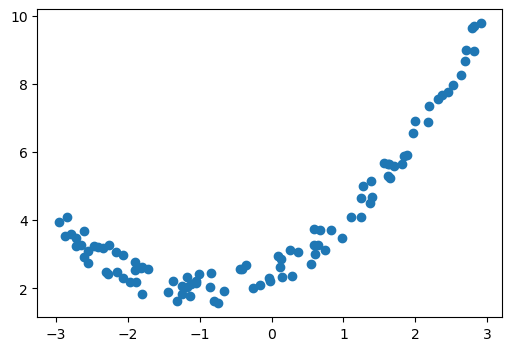

In [92]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)
m = 100
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
plt.show()

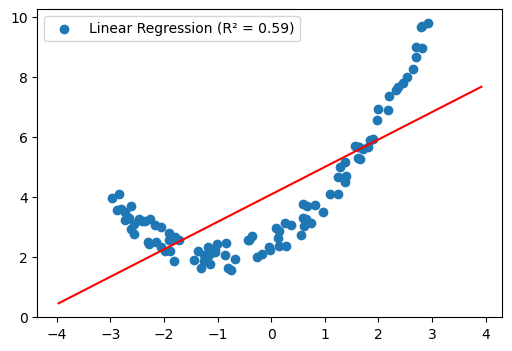

In [93]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x,y)
new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
y_pred = lin_reg.predict(new_x)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Linear Regression (R² = {lin_reg.score(x,y):.2f})'])
plt.show()

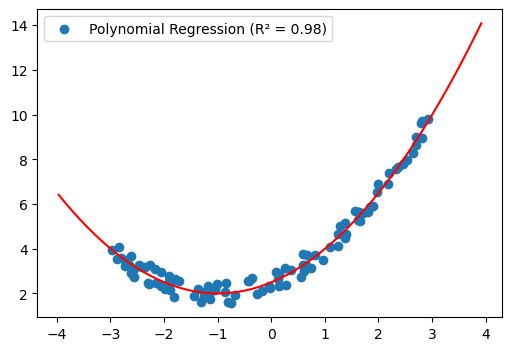

In [94]:
p_x = np.hstack([x**2, x])
lin_reg = LinearRegression()
lin_reg.fit(p_x,y)
y_pred = lin_reg.predict(np.hstack([new_x**2, new_x]))
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(p_x,y):.2f})'])
plt.show()

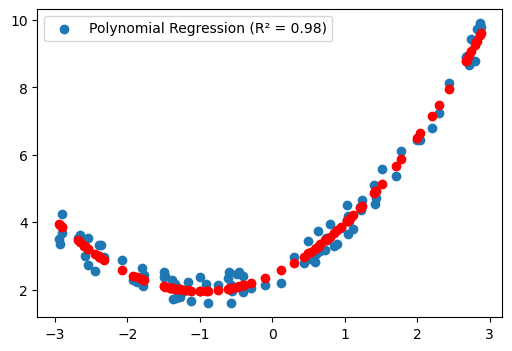

In [111]:
from sklearn.preprocessing import PolynomialFeatures
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_x = poly_features.fit_transform(x)

lin_reg = LinearRegression()
lin_reg.fit(poly_x,y)   

y_pred = lin_reg.predict(poly_x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(poly_x,y):.2f})'])
plt.show()

c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


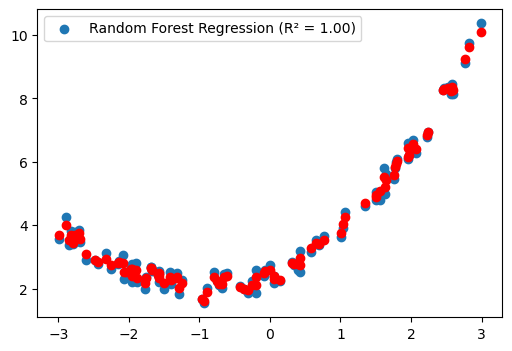

In [114]:
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(x,y)
y_predict = forest_reg.predict(x)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_predict, color='red')
plt.legend([f'Random Forest Regression (R² = {forest_reg.score(x,y):.2f})'])
plt.show()

c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


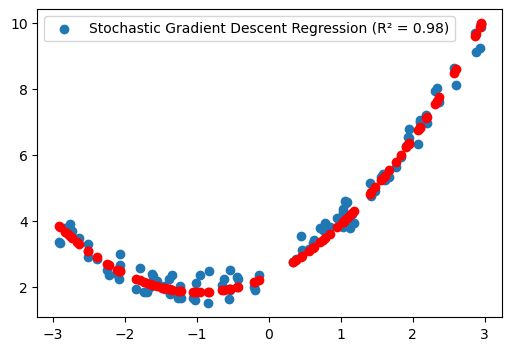

In [116]:
# 확률적 경사하강법 모델
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)
x_poly = poly.fit_transform(x)

sgd = SGDRegressor()
sgd.fit(x_poly, y)

y_pred = sgd.predict(x_poly)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Stochastic Gradient Descent Regression (R² = {sgd.score(x_poly, y):.2f})'])
plt.show()

In [132]:
# 과적합(과소적합 과대적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

# 샘플수 적게
n_samples = 20
# feature 수 많게  -> 과적합 유도
n_features = 100  # 컬럼수 또는 x의 수

x = np.random.randn(n_samples,n_features)
true_coef = np.zeros(n_features)  # 처음에는 모든 feature가 중요하지 않다고 가정
# 일부 feature만 중요하게 설정  
true_coef[:5] = [10,-7,5,3,-2]  # 실제로 앞의 5개만 y에 영향을 줌  나머지 95개는 노이즈
# true_coef 각 변수들의 가중치

# 타겟을 생성  y = 10x1 + (-7x2) + 5x3 + ....
y = x @ true_coef + np.random.rand(n_samples)*5  # 정규분포 노이즈  , 표준편차 5 --> 큰 노이즈

# 일반선형회귀
from sklearn.model_selection import train_test_split
# 학습
# 결정계수.. score 학습용데이터, 테스트데이터
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(x_train,y_train)

lr.score(x_train,y_train),  lr.score(x_test, y_test)

(1.0, 0.3977376279359226)

In [153]:
# 모델이 노이즈까지 학습
# 계수가(가중치가) 비정상적으로 커짐
# 해결방안.. 규제(Regularization)
# Ridge(L2)
    #  loss = MSE + 알파*sum(가중치**2) --> 계수(가중치) 전체적으로작게 만듦, 모든 feature유지,안정적
# Lasso(L1)
    #  loss = MSE + 알파*sum(|가중치|) --> 일부 계수(가중치)를 0으로 만들어 버림, 자동 feature selection

from sklearn.linear_model import Ridge
ridge = Ridge(alpha=30)
ridge.fit(x_train,y_train)
ridge.score(x_train,y_train), ridge.score(x_test,y_test)

(0.9432168631266318, 0.37901009934554386)

In [154]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=2)
lasso.fit(x_train,y_train)
lasso.score(x_train,y_train), lasso.score(x_test,y_test)

(0.9369715939308924, 0.5467446014495737)

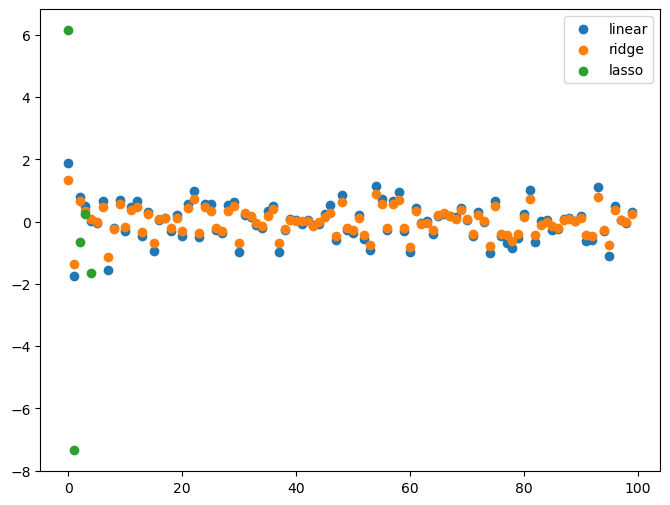

In [160]:
# 계수비교
import matplotlib.pylab as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(lr.coef_[lr.coef_ != 0])), lr.coef_[lr.coef_ != 0], label='linear')
ax.scatter(np.arange(len(ridge.coef_[ridge.coef_ != 0])), ridge.coef_[ridge.coef_ != 0], label='ridge')
ax.scatter(np.arange(len(lasso.coef_[lasso.coef_ != 0])), lasso.coef_[lasso.coef_ != 0], label='lasso')
plt.legend()
plt.show()

# linear 계수폭팔(과적합)  Ridge  전체적으로 작아짐  Lasso  일부 계수는 0으로 만들어 버림